## Homework 5
MSDS 604 Time Series Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import itertools
import warnings
import os
import seaborn as sns

warnings.filterwarnings('ignore')
# Set the working directory
os.chdir('/Users/tomas/Documents/02d-USF-MSDS/MSDS604/hw5')

/opt/anaconda3/envs/ML/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup & Data Loading
Load the dataset, ensure the date is the index, and separate the last 30 days as the holdout/test set to serve as the "future" 30 days to forecast in Q3 and Q4.

In [3]:
# Load data
df = pd.read_csv('retail_sales.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print(f"Total historical data shape: {df.shape}")
display(df.tail())

Total historical data shape: (1096, 3)


,sales,marketing,holiday
date,,,
2024-12-27,565.068439,99.255555,0
2024-12-28,554.868806,114.552591,0
2024-12-29,586.120976,101.038918,0
2024-12-30,541.152110,114.652802,0
2024-12-31,614.628178,98.385668,0


### Question 1: Exploratory Data Analysis
1. Plot the time series of daily sales, marketing, and holidays.


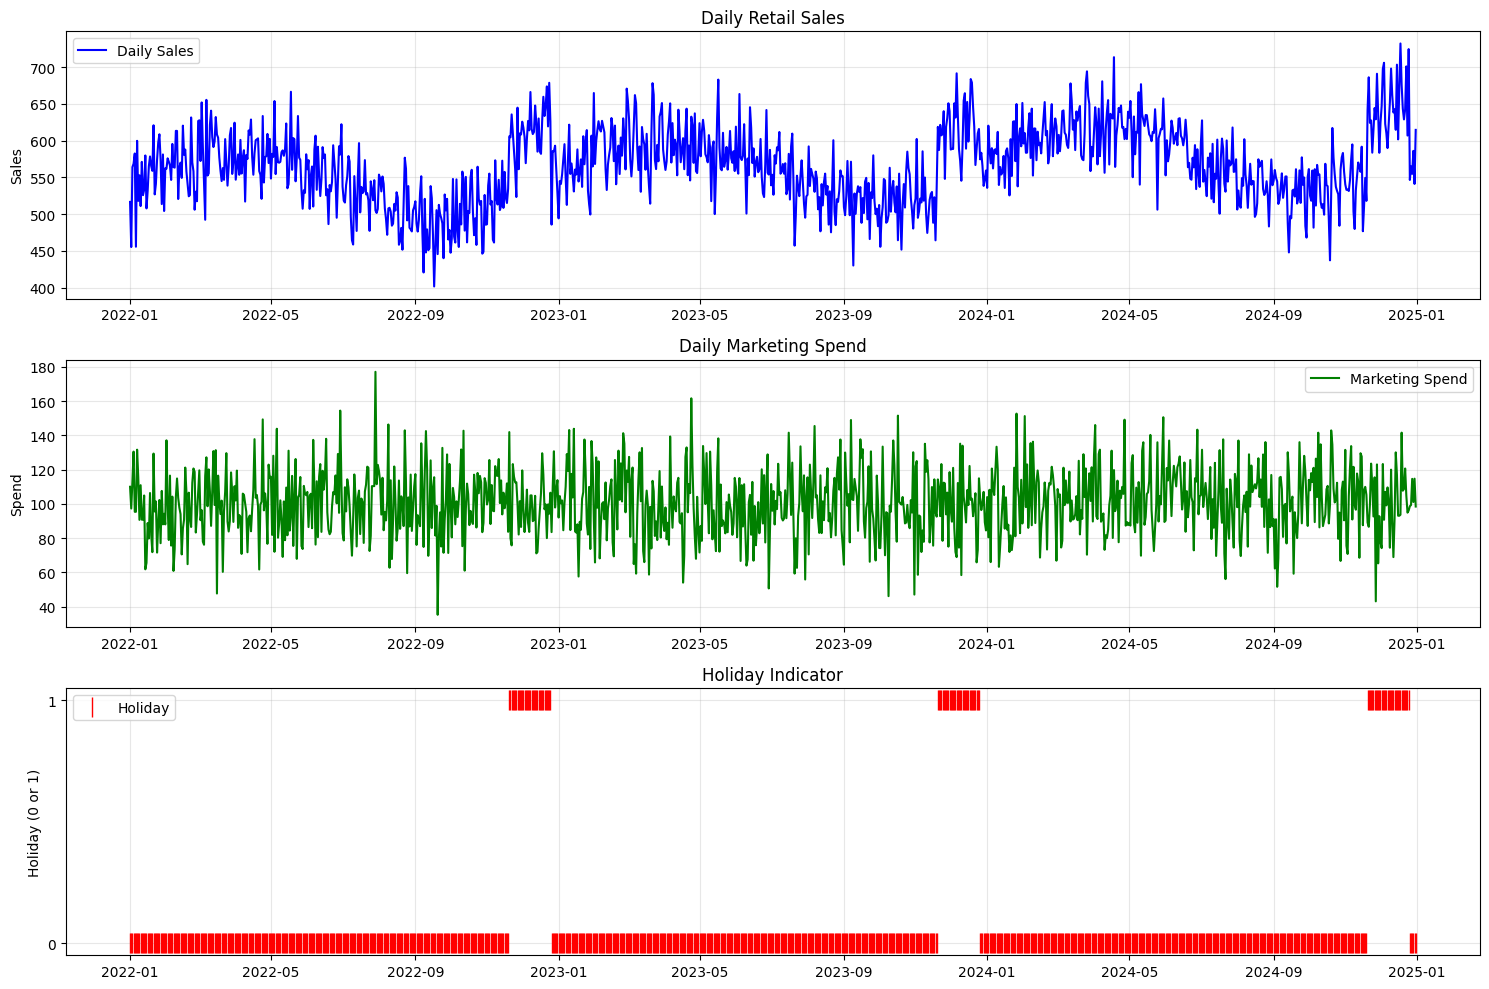

In [4]:
plt.figure(figsize=(15, 10))

# Plot 1: Daily Sales
plt.subplot(3, 1, 1)
plt.plot(df.index, df['sales'], color='blue', label='Daily Sales')
plt.title('Daily Retail Sales')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Marketing Spend
plt.subplot(3, 1, 2)
plt.plot(df.index, df['marketing'], color='green', label='Marketing Spend')
plt.title('Daily Marketing Spend')
plt.ylabel('Spend')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Holiday Indicator
plt.subplot(3, 1, 3)
plt.plot(df.index, df['holiday'], color='red', marker='|', linestyle='None', markersize=15, label='Holiday')
plt.title('Holiday Indicator')
plt.ylabel('Holiday (0 or 1)')
plt.yticks([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

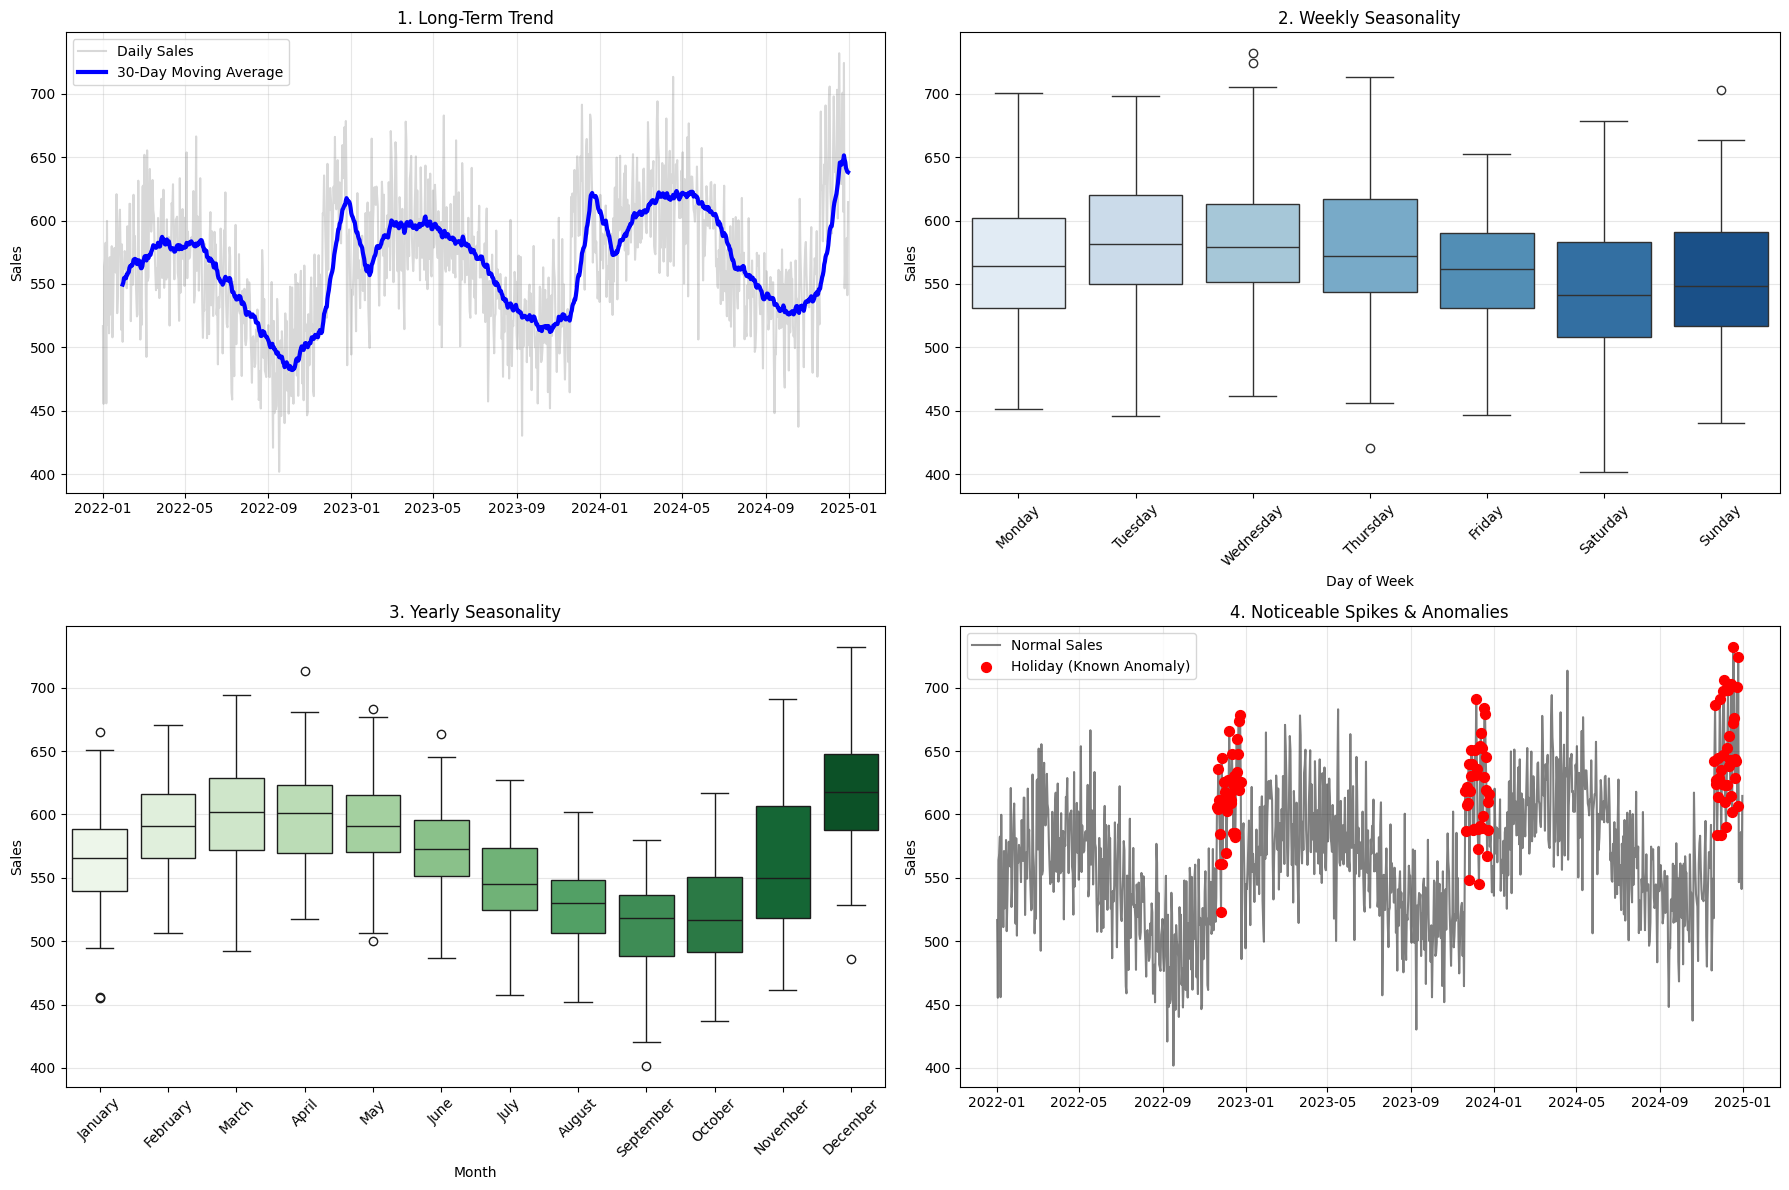

In [5]:


# Create a copy of the dataframe for EDA feature engineering
df_eda = df.copy()
df_eda['Day of Week'] = df_eda.index.day_name()
df_eda['Month'] = df_eda.index.month_name()

# Order the categorical variables so the plots show in chronological order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df_eda['Day of Week'] = pd.Categorical(df_eda['Day of Week'], categories=days_order, ordered=True)
df_eda['Month'] = pd.Categorical(df_eda['Month'], categories=months_order, ordered=True)

plt.figure(figsize=(18, 12))

# 1. The Long-Term Trend (30-Day Moving Average)
plt.subplot(2, 2, 1)
plt.plot(df_eda.index, df_eda['sales'], alpha=0.3, color='gray', label='Daily Sales')
plt.plot(df_eda.index, df_eda['sales'].rolling(window=30).mean(), color='blue', linewidth=3, label='30-Day Moving Average')
plt.title('1. Long-Term Trend')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Weekly Seasonality (Boxplots by Day of Week)
plt.subplot(2, 2, 2)
sns.boxplot(x='Day of Week', y='sales', data=df_eda, palette='Blues')
plt.title('2. Weekly Seasonality')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)

# 3. Yearly Seasonality (Boxplots by Month)
plt.subplot(2, 2, 3)
sns.boxplot(x='Month', y='sales', data=df_eda, palette='Greens')
plt.title('3. Yearly Seasonality')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)

# 4. Spikes and Anomalies (Holiday Overlay)
plt.subplot(2, 2, 4)
plt.plot(df_eda.index, df_eda['sales'], color='black', alpha=0.5, label='Normal Sales')
# Isolate and overlay holiday data points
holidays = df_eda[df_eda['holiday'] == 1]
plt.scatter(holidays.index, holidays['sales'], color='red', s=50, label='Holiday (Known Anomaly)', zorder=5)
plt.title('4. Noticeable Spikes & Anomalies')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2. Visually inspect and describe:
- The long-term trend
- Weekly seasonality a
- Yearly seasonality
- Any noticeable spikes or anomalies

**Interpretation of EDA:**
There is a clear yearly trend with daily sales increasing toward the end of each calendar year, around the holidays.
# NEED TO COMMENT ON TREND, ETC.

### Question 2: Rolling Cross-Validation & Differencing Parameters
Before running the cross-validation grid search, we will programmatically determine the optimal standard differencing (`d`) and seasonal differencing (`D`) to save computation time.

In [9]:
# Function to determine 'd' using Augmented Dickey-Fuller (ADF) Test
def determine_d(series, max_d=2):
    test_series = series.copy()
    for d in range(max_d + 1):
        p_val = adfuller(test_series.dropna())[1]
        if p_val < 0.05:
            return d
        test_series = test_series.diff()
    return max_d

# Function to determine 'D' by checking if seasonal differencing reduces variance
def determine_D(series, m=7):
    var_orig = series.var()
    var_diff = series.diff(m).var()
    if var_diff < var_orig:
        return 1
    return 0

# Calculate optimal d and D on the training set
optimal_d = determine_d(df['sales'])
optimal_D = determine_D(df['sales'], m=7)

print(f"Optimal standard differencing (d) based on ADF test: {optimal_d}")
print(f"Optimal seasonal differencing (D) based on variance reduction: {optimal_D}")

Optimal standard differencing (d) based on ADF test: 1
Optimal seasonal differencing (D) based on variance reduction: 1


In [10]:
def rolling_cv_sarimax(data, target_col, exog_cols, p_grid, d_grid, q_grid, P_grid, D_grid, Q_grid, m=7, k=5, horizon=30):
    """
    Rolling (expanding window) cross-validation for SARIMAX.
    """
    param_grid = list(itertools.product(p_grid, d_grid, q_grid, P_grid, D_grid, Q_grid))
    total_iters = len(param_grid)
    print(f"Total parameter combinations to test: {total_iters}")
    print("-" * 80)
    
    best_rmse = float('inf')
    best_params = None
    all_results = []
    
    for idx, params in enumerate(param_grid, 1):
        p, d, q, P, D, Q = params
        fold_rmses = []
        
        try:
            # Evaluate over k folds
            for i in range(k, 0, -1):
                # Calculate train and test indices for this fold
                train_end = len(data) - (i * horizon)
                test_end = train_end + horizon
                
                train_fold = data.iloc[:train_end]
                test_fold = data.iloc[train_end:test_end]
                
                # Fit model
                model = SARIMAX(train_fold[target_col], 
                                exog=train_fold[exog_cols],
                                order=(p, d, q), 
                                seasonal_order=(P, D, Q, m),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                res = model.fit(disp=False)
                
                # Direct Multi-step Forecast
                forecast = res.forecast(steps=horizon, exog=test_fold[exog_cols])
                rmse = np.sqrt(mean_squared_error(test_fold[target_col], forecast))
                fold_rmses.append(rmse)
                
            avg_rmse = np.mean(fold_rmses)
            all_results.append((params, avg_rmse))
            
            # Format the individual fold RMSEs for printing
            folds_str = ", ".join([f"{f_rmse:.1f}" for f_rmse in fold_rmses])
            
            # Check if this is the best model so far and format the print output
            highlight = ""
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                best_params = params
                highlight = "   <--- NEW BEST MODEL!"
            
            print(f"Iter {idx}/{total_iters} | Params: (p={p},d={d},q={q})x(P={P},D={D},Q={Q},m={m})")
            print(f"    Folds: [{folds_str}] | Avg RMSE: {avg_rmse:.4f}{highlight}")
                
        except Exception as e:
            # Catch convergence issues or LinAlg errors for incompatible parameter combinations
            print(f"Iter {idx}/{total_iters} | Params: (p={p},d={d},q={q})x(P={P},D={D},Q={Q},m={m}) | FAILED (LinAlg/Convergence)")
            continue
            
    print("-" * 80)
    print(f"Grid Search Complete! Best RMSE: {best_rmse:.4f}")
    return best_params, best_rmse

In [14]:
# 1. Forecast Marketing using a univariate Prophet model
prophet_mkt = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
df_mkt_train = df.reset_index()[['date', 'marketing']].rename(columns={'date': 'ds', 'marketing': 'y'})
prophet_mkt.fit(df_mkt_train)

# Create future dataframe for 30 days
future_dates = prophet_mkt.make_future_dataframe(periods=30, freq='D')
mkt_forecast = prophet_mkt.predict(future_dates)

# Extract only the future 30 days
future_30 = mkt_forecast.iloc[-30:][['ds', 'yhat']].rename(columns={'ds': 'date', 'yhat': 'marketing'})
future_30.set_index('date', inplace=True)

# 2. Add the Holiday assumption (0 for January)
future_30['holiday'] = 0

print("Forecasted Exogenous Variables for the Next 30 Days (Jan 2025):")
display(future_30.head(30))

23:53:09 - cmdstanpy - INFO - Chain [1] start processing
23:53:09 - cmdstanpy - INFO - Chain [1] done processing


Forecasted Exogenous Variables for the Next 30 Days (Jan 2025):


,marketing,holiday
date,,
2025-01-01,103.851293,0
2025-01-02,106.002159,0
2025-01-03,107.592131,0
2025-01-04,106.682203,0
2025-01-05,105.505905,0
2025-01-06,101.426020,0
2025-01-07,104.752176,0
2025-01-08,100.751430,0
2025-01-09,102.580006,0


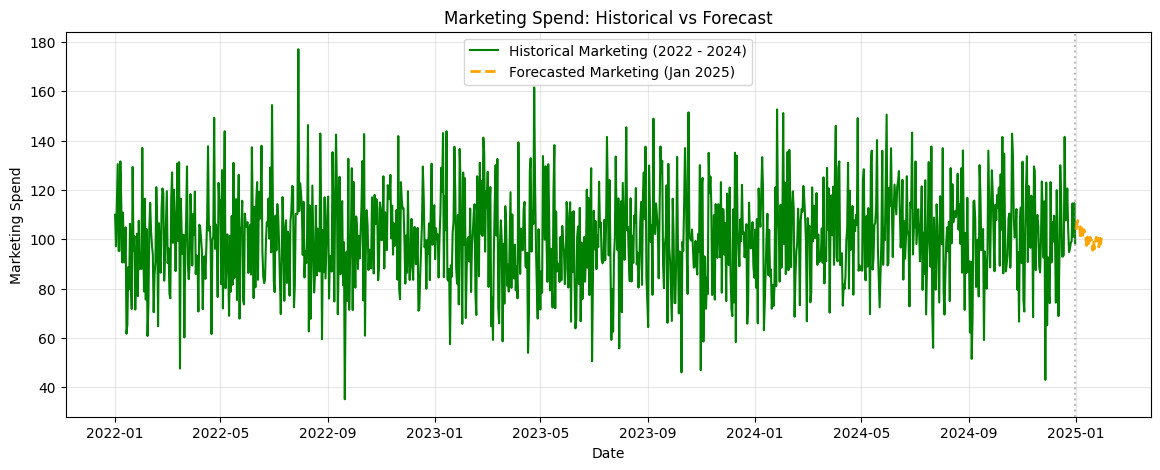

In [37]:
# Plotting Current vs Forecasted Marketing
plt.figure(figsize=(14, 5))

# Plot historical marketing data
plt.plot(df.index, df['marketing'], label='Historical Marketing (2022 - 2024)', color='green')

# Plot forecasted marketing data
plt.plot(future_30.index, future_30['marketing'], label='Forecasted Marketing (Jan 2025)', color='orange', linestyle='--', linewidth=2)

# Formatting
plt.title('Marketing Spend: Historical vs Forecast')
plt.ylabel('Marketing Spend')
plt.xlabel('Date')
plt.axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.5) # Line separating past and future
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

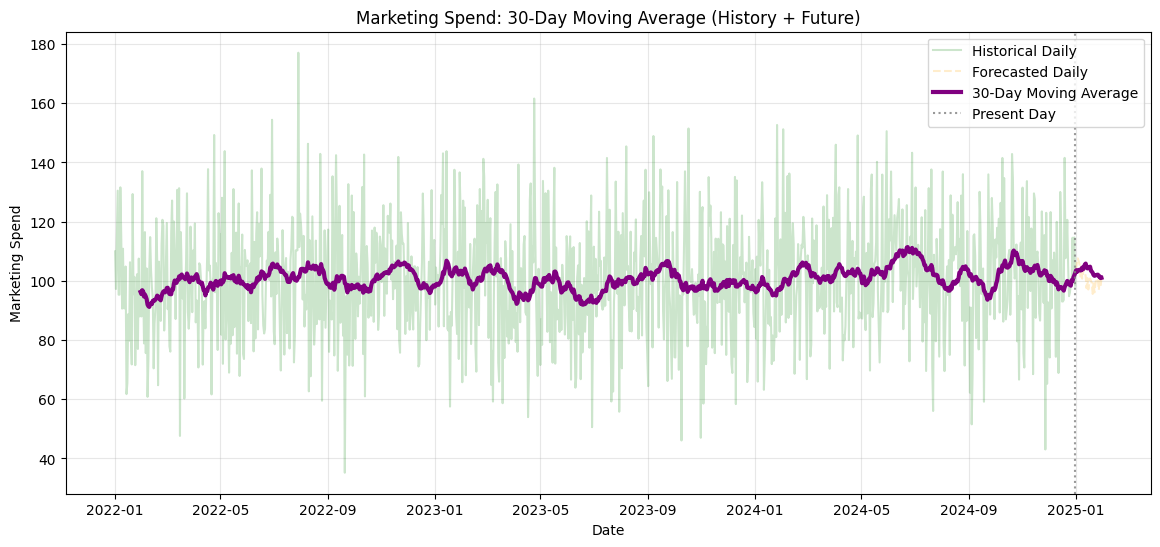

In [40]:
# Combine historical and future marketing data into one series
combined_marketing = pd.concat([df['marketing'], future_30['marketing']])

# Calculate the 30-day moving average across the continuous timeline
marketing_ma30 = combined_marketing.rolling(window=30).mean()

# Plotting
plt.figure(figsize=(14, 6))

# Plot the raw data in the background (faded)
plt.plot(df.index, df['marketing'], color='green', alpha=0.2, label='Historical Daily')
plt.plot(future_30.index, future_30['marketing'], color='orange', alpha=0.2, linestyle='--', label='Forecasted Daily')

# Plot the 30-Day Moving Average on top
plt.plot(combined_marketing.index, marketing_ma30, label='30-Day Moving Average', color='purple', linewidth=3)

# Formatting
plt.title('Marketing Spend: 30-Day Moving Average (History + Future)')
plt.ylabel('Marketing Spend')
plt.xlabel('Date')
plt.axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.8, label='Present Day') # Line separating past and future
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Question 3: SARIMAX Modeling
Using the cross-validation function above, we will search over an expanded grid for p, q, P, and Q, while plugging in our algorithmically determined lists for d and D.

In [21]:
# Define grids (as lists so they can be modified later if needed)
# p_grid = [0, 1, 2, 3]
p_grid = [0,1]
d_grid = [optimal_d] 
# q_grid = [0, 1, 2, 3]
q_grid = [0,1]
# P_grid = [0, 1, 2]
P_grid = [0, 1]
D_grid = [optimal_D]
# Q_grid = [0, 1, 2]
Q_grid = [0,1]

exogenous_features = ['marketing', 'holiday']

# Note: This may take a while to run depending on CPU (144 combinations * 5 folds)
best_order, best_score = rolling_cv_sarimax(
    data=df, 
    target_col='sales', 
    exog_cols=exogenous_features, 
    p_grid=p_grid, d_grid=d_grid, q_grid=q_grid, 
    P_grid=P_grid, D_grid=D_grid, Q_grid=Q_grid, 
    k=5, horizon=30
)

print(f"Best SARIMAX Parameters (p,d,q)x(P,D,Q,7): {best_order}")
print(f"Best Cross-Validation RMSE: {best_score:.4f}")

Total parameter combinations to test: 16
--------------------------------------------------------------------------------
Iter 1/16 | Params: (p=0,d=1,q=0)x(P=0,D=1,Q=0,m=7)
    Folds: [141.9, 94.2, 181.8, 36.5, 128.8] | Avg RMSE: 116.6360   <--- NEW BEST MODEL!
Iter 2/16 | Params: (p=0,d=1,q=0)x(P=0,D=1,Q=1,m=7)
    Folds: [24.4, 51.5, 40.5, 30.4, 34.4] | Avg RMSE: 36.2225   <--- NEW BEST MODEL!
Iter 3/16 | Params: (p=0,d=1,q=0)x(P=1,D=1,Q=0,m=7)
    Folds: [116.4, 54.5, 97.4, 51.8, 83.8] | Avg RMSE: 80.7757
Iter 4/16 | Params: (p=0,d=1,q=0)x(P=1,D=1,Q=1,m=7)
    Folds: [25.0, 50.6, 42.9, 30.4, 33.6] | Avg RMSE: 36.5156
Iter 5/16 | Params: (p=0,d=1,q=1)x(P=0,D=1,Q=0,m=7)
    Folds: [48.6, 48.9, 36.1, 36.8, 45.3] | Avg RMSE: 43.1396
Iter 6/16 | Params: (p=0,d=1,q=1)x(P=0,D=1,Q=1,m=7)
    Folds: [27.3, 31.3, 31.1, 28.0, 39.7] | Avg RMSE: 31.5067   <--- NEW BEST MODEL!
Iter 7/16 | Params: (p=0,d=1,q=1)x(P=1,D=1,Q=0,m=7)
    Folds: [35.7, 38.1, 36.1, 35.9, 46.9] | Avg RMSE: 38.5342
Iter 8

In [24]:
# Refit the winning model on the entire training data
p, d, q, P, D, Q = best_order

final_sarimax = SARIMAX(df['sales'], 
                        exog=df[exogenous_features],
                        order=(p, d, q), 
                        seasonal_order=(P, D, Q, 7),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarimax_res = final_sarimax.fit(disp=False)

# Forecast the next 30 days using the test set's exogenous variables
sarimax_forecast = sarimax_res.forecast(steps=30, exog=future_30[exogenous_features])

print("SARIMAX 30-Day Forecast Values:")
display(pd.DataFrame({'Forecasted Sales': sarimax_forecast}))
# print(f"SARIMAX Holdout Test RMSE: {test_rmse_sarimax:.4f}")

SARIMAX 30-Day Forecast Values:


,Forecasted Sales
2025-01-01,590.833514
2025-01-02,584.312680
2025-01-03,567.482078
2025-01-04,551.179351
2025-01-05,562.719640
2025-01-06,573.770289
2025-01-07,590.286943
2025-01-08,590.255581
2025-01-09,583.651904
2025-01-10,566.758379


### Question 4: Prophet Modeling
Fit a Prophet model including yearly seasonality, weekly seasonality, and our two exogenous regressors.

In [43]:
def rolling_cv_prophet(data, k=5, horizon=30):
    """
    Rolling (expanding window) cross-validation for Prophet 
    to match the SARIMAX evaluation perfectly.
    """
    print("Running 5-Fold Cross Validation for Prophet...")
    print("-" * 60)
    fold_rmses = []
    
    # Evaluate over k folds using history
    for i in range(k, 0, -1):
        # Calculate train and test indices for this fold
        train_end = len(data) - (i * horizon)
        test_end = train_end + horizon
        
        train_fold = data.iloc[:train_end].reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
        test_fold = data.iloc[train_end:test_end].reset_index().rename(columns={'date': 'ds', 'sales': 'y'})
        
        # Initialize and fit Prophet
        m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        m.add_regressor('marketing')
        m.add_regressor('holiday')
        m.fit(train_fold)
        
        # Forecast
        future = test_fold[['ds', 'marketing', 'holiday']]
        forecast = m.predict(future)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(test_fold['y'], forecast['yhat']))
        fold_rmses.append(rmse)
        
    avg_rmse = np.mean(fold_rmses)
    folds_str = ", ".join([f"{f_rmse:.1f}" for f_rmse in fold_rmses])
    
    print(f"Prophet CV Folds: [{folds_str}]")
    print(f"Prophet Avg CV RMSE: {avg_rmse:.4f}")
    print("-" * 60)
    
    return avg_rmse

# Run the Prophet Cross-Validation
prophet_cv_score = rolling_cv_prophet(df, k=5, horizon=30)

print(f"COMPARISON:")
print(f"Best SARIMAX CV RMSE: {best_score:.4f}")
print(f"Prophet CV RMSE:      {prophet_cv_score:.4f}")

00:14:00 - cmdstanpy - INFO - Chain [1] start processing
00:14:00 - cmdstanpy - INFO - Chain [1] done processing
00:14:00 - cmdstanpy - INFO - Chain [1] start processing


Running 5-Fold Cross Validation for Prophet...
------------------------------------------------------------


00:14:00 - cmdstanpy - INFO - Chain [1] done processing
00:14:00 - cmdstanpy - INFO - Chain [1] start processing
00:14:00 - cmdstanpy - INFO - Chain [1] done processing
00:14:01 - cmdstanpy - INFO - Chain [1] start processing
00:14:01 - cmdstanpy - INFO - Chain [1] done processing
00:14:01 - cmdstanpy - INFO - Chain [1] start processing
00:14:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet CV Folds: [24.6, 26.2, 29.7, 26.4, 33.0]
Prophet Avg CV RMSE: 27.9532
------------------------------------------------------------
COMPARISON:
Best SARIMAX CV RMSE: 31.5067
Prophet CV RMSE:      27.9532


In [ ]:
# Format training data for Prophet
df_prophet_train = df.reset_index().rename(columns={'date': 'ds', 'sales': 'y'})

# Initialize Prophet model with required seasonalities
prophet_sales = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Add regressors
prophet_sales.add_regressor('marketing')
prophet_sales.add_regressor('holiday')

# Fit model on the full historical dataset
prophet_sales.fit(df_prophet_train)

# Format the future exogenous data for forecasting
future_prophet_exog = future_30.reset_index().rename(columns={'date': 'ds'})

# Generate Forecast
prophet_forecast_full = prophet_sales.predict(future_prophet_exog)

# Extract just the point predictions and set index
prophet_forecast = prophet_forecast_full[['ds', 'yhat']].set_index('ds')
prophet_forecast.index.name = 'date'
prophet_forecast_series = prophet_forecast['yhat']

print("Prophet 30-Day Forecast Values (Jan 2025):")
display(pd.DataFrame({'Forecasted Sales': prophet_forecast_series}))


00:13:35 - cmdstanpy - INFO - Chain [1] start processing
00:13:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet 30-Day Forecast Values (Jan 2025):


,Forecasted Sales
date,
2025-01-01,598.744828
2025-01-02,593.090777
2025-01-03,577.204474
2025-01-04,562.291787
2025-01-05,572.743254
2025-01-06,585.143947
2025-01-07,603.581595
2025-01-08,604.263047
2025-01-09,599.101511


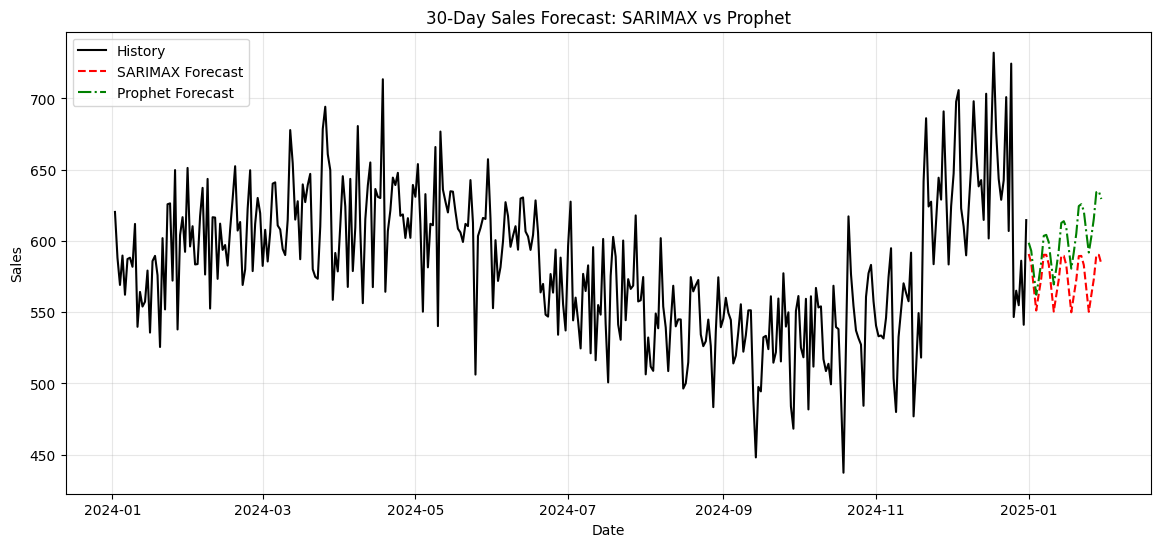

In [36]:
# Final Visual Comparison of the 30-Day Forecasts
plt.figure(figsize=(14, 6))

# Plot the last 60 days of history
plt.plot(df.index[-365:], df['sales'][-365:], label='History', color='black')

# Plot actual test values
# plt.plot(future_30.index, test['sales'], label='Actual Sales (Forecast)', color='blue', linewidth=2)

# Plot forecasts
plt.plot(future_30.index, sarimax_forecast, label=f'SARIMAX Forecast', color='red', linestyle='--')
plt.plot(future_30.index, prophet_forecast_series, label=f'Prophet Forecast', color='green', linestyle='-.')

plt.title('30-Day Sales Forecast: SARIMAX vs Prophet')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
# Format the SARIMAX forecast into a neat DataFrame
df_sarimax_out = pd.DataFrame({'Forecasted_Sales': sarimax_forecast})
df_sarimax_out.index.name = 'Date'

# Format the Prophet forecast into a neat DataFrame
df_prophet_out = pd.DataFrame({'Forecasted_Sales': prophet_forecast_series})
df_prophet_out.index.name = 'Date'

# Export both to CSV in the current working directory
df_sarimax_out.to_csv('sarimax_forecast_jan2025.csv')
df_prophet_out.to_csv('prophet_forecast_jan2025.csv')

print("Success! Both forecasts have been saved to your folder.")

Success! Both forecasts have been saved to your folder.
